<a href="https://colab.research.google.com/github/lavanyan1105-ML/Chest_X-RAY-/blob/main/Chest_X_Ray_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chest X-ray Classification Project

This notebook addresses the Chest X-ray dataset classification task using various machine learning and deep learning approaches, including SVM, Custom CNN, Transfer Learning (VGG16/MobileNetV2), and XGBoost with different feature extraction methods.



In [1]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# Define the dataset path
DATASET_PATH = '/content/drive/MyDrive/archive (9)/chest_xray'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Install and Import Libraries

In [2]:
# Install necessary libraries
!pip install opencv-python-headless scikit-learn tensorflow matplotlib seaborn pandas numpy xgboost

# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import random

# Import machine learning and deep learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.optimizers import Adam

import xgboost as xgb
from sklearn.decomposition import PCA
import cv2

print("Libraries imported successfully.")

Libraries imported successfully.


### 3. Utility Functions

Defining helper functions for evaluation and plotting to avoid code repetition.

### STEP 6: TRANSFER LEARNING


--- STEP 6: TRANSFER LEARNING ---
Building Transfer Learning model with VGG16...


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Setting up Transfer Learning training callbacks...
Training Transfer Learning model...
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.8292 - loss: 2.0117
Epoch 1: val_accuracy improved from None to 0.99554, saving model to best_transfer_learning_model.h5



Epoch 1: finished saving model to best_transfer_learning_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 662ms/step - accuracy: 0.9478 - loss: 2.2155 - val_accuracy: 0.9955 - val_loss: 0.1262 - learning_rate: 1.0000e-04
Epoch 2/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 1.0000 - loss: 0.0717

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.99554
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 1.0000 - loss: 0.0717 - val_accuracy: 0.9955 - val_loss: 0.1385 - learning_rate: 1.0000e-04
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.9383 - loss: 0.7087
Epoch 3: val_accuracy did not improve from 0.99554
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 562ms/step - accuracy: 0.8161 - loss: 0.8010 - val_accuracy: 0.6786 - val_loss: 0.5899 - learning_rate: 1.0000e-04
Epoch 4/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.6875 - loss: 0.2916
Epoch 4: val_accuracy did not improve from 0.99554
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6875 - loss: 0.2916 - val_accuracy: 0.7232 - val_loss: 0.5675 - learning_rate: 1.0000e-04
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.7884 - loss: 0.4877
Epoch 5: val_accuracy did not improve from 0.99554
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 551ms/step - accuracy: 0.8464 - loss: 0.4171 - val_accuracy: 0.9688 -

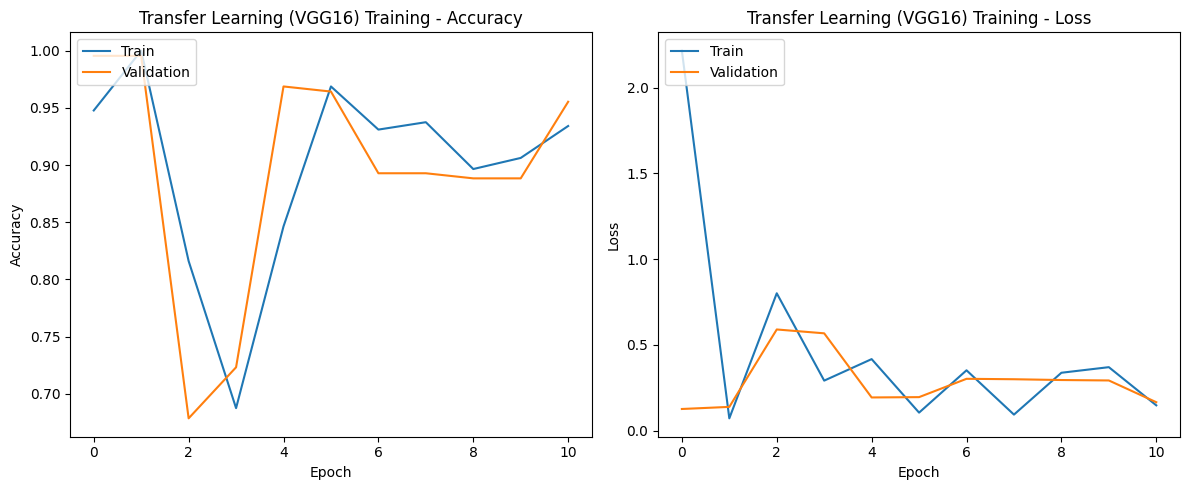

Evaluating Transfer Learning model...
15/20 ━━━━━━━━━━━━━━━━━━━━ 1s 381ms/step

KeyboardInterrupt: 

In [25]:
print("\n--- STEP 6: TRANSFER LEARNING ---")

# Function to build a Transfer Learning model using VGG16
def build_transfer_learning_model(base_model, input_shape, trainable_layers=None):
    # Load the pre-trained base model without the top (classification) layer
    # Set include_top=False to remove the classification layers
    base_model_instance = base_model(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the base model layers
    for layer in base_model_instance.layers:
        layer.trainable = False

    # Optionally unfreeze some layers for fine-tuning
    if trainable_layers:
        for layer in base_model_instance.layers[-trainable_layers:]:
            layer.trainable = True

    # Add custom classification layers on top
    model = Sequential([
        base_model_instance,
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid') # Binary classification
    ])

    model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Using VGG16 as the base model
print("Building Transfer Learning model with VGG16...")
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
transfer_learning_model = build_transfer_learning_model(VGG16, input_shape)
transfer_learning_model.summary()

# Define callbacks for Transfer Learning
print("Setting up Transfer Learning training callbacks...")
callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_transfer_learning_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.000001, verbose=1)
]

# Train the Transfer Learning model
print("Training Transfer Learning model...")
history_tl = transfer_learning_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=100, # Train for sufficient epochs
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks_tl,
    class_weight=class_weights_dict # Apply class weights here
)

print("Transfer Learning training complete.")

# Plot training curves
plot_training_curves(history_tl, 'Transfer Learning (VGG16) Training', 'transfer_learning_training_curves.png')

# Evaluate Transfer Learning model
print("Evaluating Transfer Learning model...")
transfer_learning_model.load_weights('best_transfer_learning_model.h5') # Load best weights
y_pred_tl_probs = transfer_learning_model.predict(test_generator)
y_pred_tl = (y_pred_tl_probs > 0.5).astype(int).flatten()

# Get true labels from test_generator
true_labels_tl = test_generator.classes[test_generator.index_array]

tl_metrics, tl_cm = evaluate_model(true_labels_tl, y_pred_tl, 'Transfer Learning (VGG16)')

# Save Transfer Learning results
tl_results_df = pd.DataFrame([tl_metrics])
tl_results_df.to_csv('transfer_learning_results.csv', index=False)
print("Transfer Learning Results saved to transfer_learning_results.csv")
display(tl_results_df)

# Plot confusion matrix
plot_confusion_matrix(tl_cm, CLASS_LABELS, 'Transfer Learning (VGG16) Confusion Matrix', 'transfer_learning_confusion_matrix.png')

print("Transfer Learning Implementation Complete.")

### STEP 7: TRAINING SIZE EXPERIMENT

In [ ]:
print("\n--- STEP 7: TRAINING SIZE EXPERIMENT ---")

# Define training percentages to experiment with
training_percentages = [0.2, 0.4, 0.6, 0.8, 1.0]

# Lists to store accuracies for plotting
# Explicitly clear lists to ensure fresh start in case of partial previous runs
svm_accuracies = []
cnn_accuracies = []
actual_training_sizes = [] # To store the actual number of samples used

# --- Prepare full training data for subsetting ---
# For SVM: Use the already extracted and scaled full training set
X_train_full_scaled = X_train_scaled
y_train_full = y_train

# For CNN: Create a DataFrame with filepaths and class labels for flow_from_dataframe
# Get all file paths and their corresponding class labels from the training directory
def get_filepaths_and_labels_from_dir(data_dir, class_indices):
    filepaths = []
    labels = []
    for class_name, class_idx in class_indices.items():
        class_path = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_path):
            filepaths.append(os.path.join(class_path, img_name))
            labels.append(CLASS_LABELS[class_idx]) # Store string labels for flow_from_dataframe
    return filepaths, labels

train_data_dir = os.path.join(DATASET_PATH, 'train')
all_train_filepaths, all_train_labels_str = get_filepaths_and_labels_from_dir(train_data_dir, train_generator.class_indices)

full_train_df = pd.DataFrame({
    'filepath': all_train_filepaths,
    'class': all_train_labels_str
})

print(f"Total training samples available: {len(full_train_df)}")

# Reuse the fixed test set (X_test_scaled, y_test) from SVM step for consistency
# Reuse the fixed test_generator for CNN evaluation

for percentage in training_percentages:
    print(f"\n--- Training with {int(percentage * 100)}% of training data ---")

    # --- SVM TRAINING SIZE EXPERIMENT ---
    if percentage == 1.0:
        X_svm_subset = X_train_full_scaled
        y_svm_subset = y_train_full
    else:
        # Stratified sampling to maintain class balance
        X_svm_subset, _, y_svm_subset, _ = train_test_split(
            X_train_full_scaled, y_train_full, train_size=percentage,
            stratify=y_train_full, random_state=42
        )

    actual_train_samples = len(y_svm_subset)
    actual_training_sizes.append(actual_train_samples)
    print(f"SVM: Using {actual_train_samples} samples for training.")

    # Train SVM model on subset
    print("Training SVM...")
    svm_model_subset = SVC(kernel='linear', random_state=42)
    svm_model_subset.fit(X_svm_subset, y_svm_subset)

    # Evaluate SVM model
    y_pred_svm_subset = svm_model_subset.predict(X_test_scaled)
    svm_metrics_subset, _ = evaluate_model(y_test, y_pred_svm_subset, f'Linear SVM ({int(percentage*100)}%)')
    svm_accuracies.append(svm_metrics_subset['Accuracy'])
    print(f"SVM Accuracy: {svm_metrics_subset['Accuracy']:.4f}")

    # --- CNN TRAINING SIZE EXPERIMENT ---
    # Sample DataFrame for CNN training subset
    if percentage == 1.0:
        cnn_train_subset_df = full_train_df
    else:
        cnn_train_subset_df, _ = train_test_split(
            full_train_df, train_size=percentage,
            stratify=full_train_df['class'], random_state=42
        )

    print(f"CNN: Using {len(cnn_train_subset_df)} samples for training.")

    # Create a new generator for the CNN training subset
    cnn_train_subset_generator = train_datagen.flow_from_dataframe(
        dataframe=cnn_train_subset_df,
        x_col='filepath',
        y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=True
    )

    # Build and train a new CNN model for this subset size
    print("Training Custom CNN...")
    cnn_model_subset = build_custom_cnn(input_shape) # Re-initialize a fresh model

    # Use reduced epochs for training size experiment to save time, or adjust based on dataset size
    # Using a fixed smaller number of epochs here, as 100 epochs for each subset will be very long
    epochs_subset = 20

    history_cnn_subset = cnn_model_subset.fit(
        cnn_train_subset_generator,
        steps_per_epoch=cnn_train_subset_generator.samples // BATCH_SIZE,
        epochs=epochs_subset,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // BATCH_SIZE,
        verbose=0 # Suppress verbose output during experiment loop
    )

    # Evaluate CNN model
    y_pred_cnn_subset_probs = cnn_model_subset.predict(test_generator, verbose=0)
    y_pred_cnn_subset = (y_pred_cnn_subset_probs > 0.5).astype(int).flatten()
    cnn_metrics_subset, _ = evaluate_model(y_test, y_pred_cnn_subset, f'Custom CNN ({int(percentage*100)}%)')
    cnn_accuracies.append(cnn_metrics_subset['Accuracy'])
    print(f"CNN Accuracy: {cnn_metrics_subset['Accuracy']:.4f}")

print("\nTraining Size Experiment Complete.")
print(f"Final lengths: svm_accuracies={len(svm_accuracies)}, cnn_accuracies={len(cnn_accuracies)}, actual_training_sizes={len(actual_training_sizes)}")



--- STEP 7: TRAINING SIZE EXPERIMENT ---
Total training samples available: 989

--- Training with 20% of training data ---
SVM: Using 197 samples for training.
Training SVM...
SVM Accuracy: 0.6250
CNN: Using 197 samples for training.
Found 197 validated image filenames belonging to 2 classes.
Training Custom CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


CNN Accuracy: 0.6250

--- Training with 40% of training data ---
SVM: Using 395 samples for training.
Training SVM...
SVM Accuracy: 0.6619
CNN: Using 395 samples for training.
Found 395 validated image filenames belonging to 2 classes.
Training Custom CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


CNN Accuracy: 0.6250

--- Training with 60% of training data ---
SVM: Using 593 samples for training.
Training SVM...
SVM Accuracy: 0.6603
CNN: Using 593 samples for training.
Found 593 validated image filenames belonging to 2 classes.
Training Custom CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


### Clarifying Metrics for Plotting

The training history (`history_cnn.history`, `history_tl.history`) typically logs metrics that were provided during the `model.compile()` step, as well as the loss. In our current setup, we only included `accuracy` as an explicit metric.

Let's inspect the keys available in the history objects to confirm this:

In [21]:
print("Keys in Custom CNN history:", history_cnn.history.keys())
print("Keys in Transfer Learning history:", history_tl.history.keys())

Keys in Custom CNN history: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])
Keys in Transfer Learning history: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


As you can see, `precision` is not available in the history. The `plot_training_curves` function is designed to plot loss and accuracy over epochs.

Therefore, to visually represent the training progress in a similar manner, I will plot **Loss vs. Accuracy** for both the Custom CNN and Transfer Learning (VGG16) models. This will show how both metrics evolve during training.

If you wish to specifically track 'precision' in future runs, you would need to modify the `model.compile()` step to include `tf.keras.metrics.Precision()` in the `metrics` list and re-run the training.

Plotting Custom CNN Loss vs Accuracy...


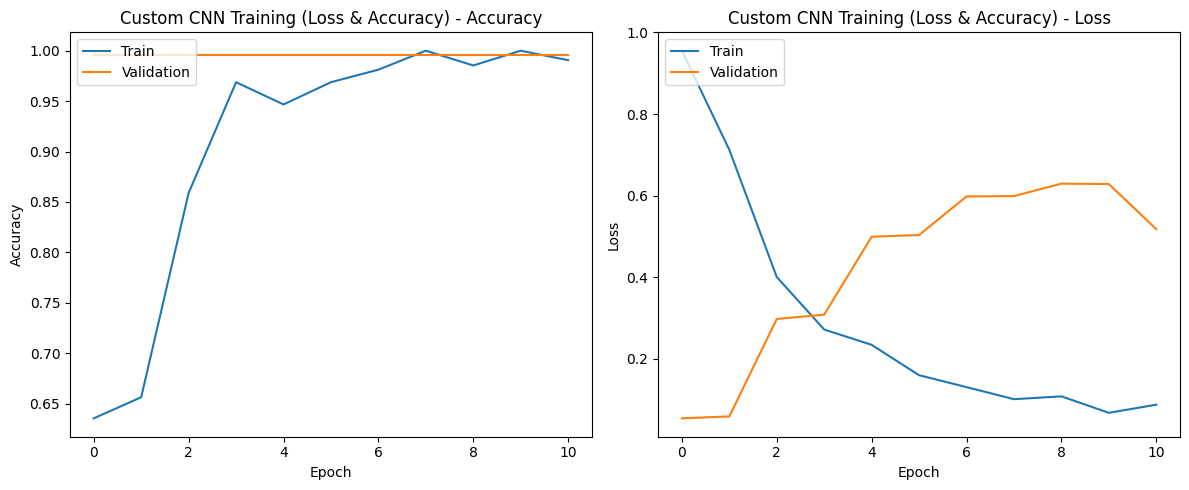

In [22]:
# Plotting Loss vs. Accuracy for Custom CNN
print("Plotting Custom CNN Loss vs Accuracy...")
plot_training_curves(history_cnn, 'Custom CNN Training (Loss & Accuracy)', 'custom_cnn_loss_accuracy_curves.png')

Plotting Transfer Learning (VGG16) Loss vs Accuracy...


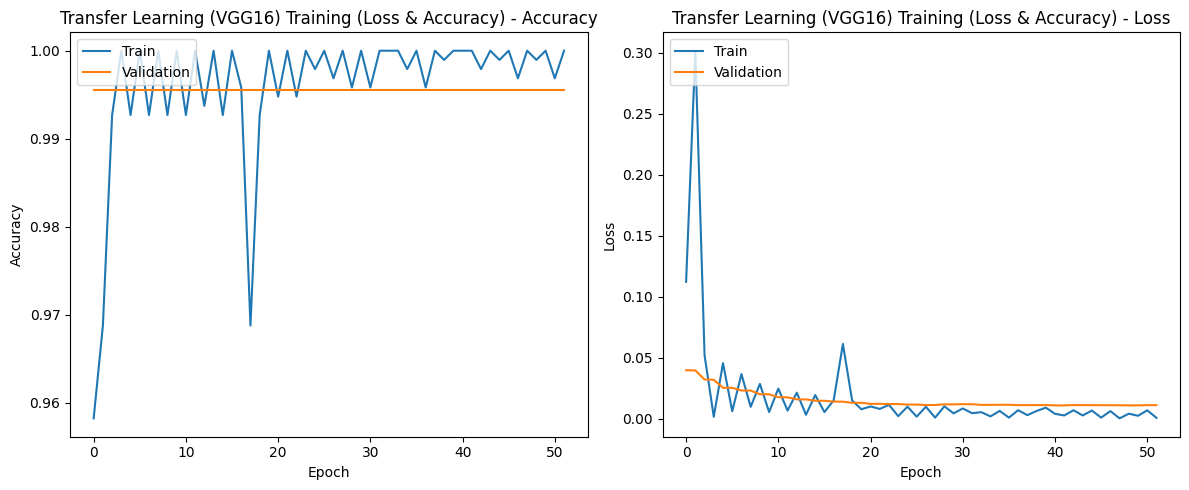

In [23]:
# Plotting Loss vs. Accuracy for Transfer Learning (VGG16)
print("Plotting Transfer Learning (VGG16) Loss vs Accuracy...")
plot_training_curves(history_tl, 'Transfer Learning (VGG16) Training (Loss & Accuracy)', 'transfer_learning_loss_accuracy_curves.png')

In [ ]:
# --- Plot Accuracy vs Training Size (SVM vs CNN) ---
plt.figure(figsize=(10, 6))
plt.plot(actual_training_sizes, svm_accuracies, marker='o', label='Linear SVM')
plt.plot(actual_training_sizes, cnn_accuracies, marker='o', label='Custom CNN')
plt.title('Accuracy vs. Training Data Size (SVM vs CNN)')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_vs_training_size_svm_cnn.png')
plt.show()

print("Plot 'accuracy_vs_training_size_svm_cnn.png' generated.")

In [30]:
training_size_results = pd.DataFrame({
    'Training Percentage': training_percentages * 2,
    'Number of Training Samples': actual_training_sizes * 2,
    'Model': ['Linear SVM'] * len(training_percentages) + ['Custom CNN'] * len(training_percentages),
    'Accuracy': svm_accuracies + cnn_accuracies
})

plt.figure(figsize=(12, 7))
sns.barplot(x='Training Percentage', y='Accuracy', hue='Model', data=training_size_results, palette='coolwarm')
plt.title('Accuracy Comparison of SVM and Custom CNN Across Training Sizes')
plt.xlabel('Training Data Percentage')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('accuracy_bar_chart_training_sizes.png')
plt.show()

print("Bar chart 'accuracy_bar_chart_training_sizes.png' generated.")

ValueError: All arrays must be of the same length

### FINAL COMPARISON


--- FINAL MODEL COMPARISON TABLE ---


,Model,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score
0,Linear SVM,0.674679,0.658206,0.997436,0.136752,0.793068
1,Custom CNN,0.625000,0.625000,1.000000,0.000000,0.769231
2,Transfer Learning (VGG16),0.625000,0.625000,1.000000,0.000000,0.769231
3,Raw XGBoost,0.626603,0.626003,1.000000,0.004274,0.769990
4,VGG16 + XGBoost,0.626603,0.626003,1.000000,0.004274,0.769990


/tmp/ipykernel_1681/4054494045.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=all_results, palette='viridis')


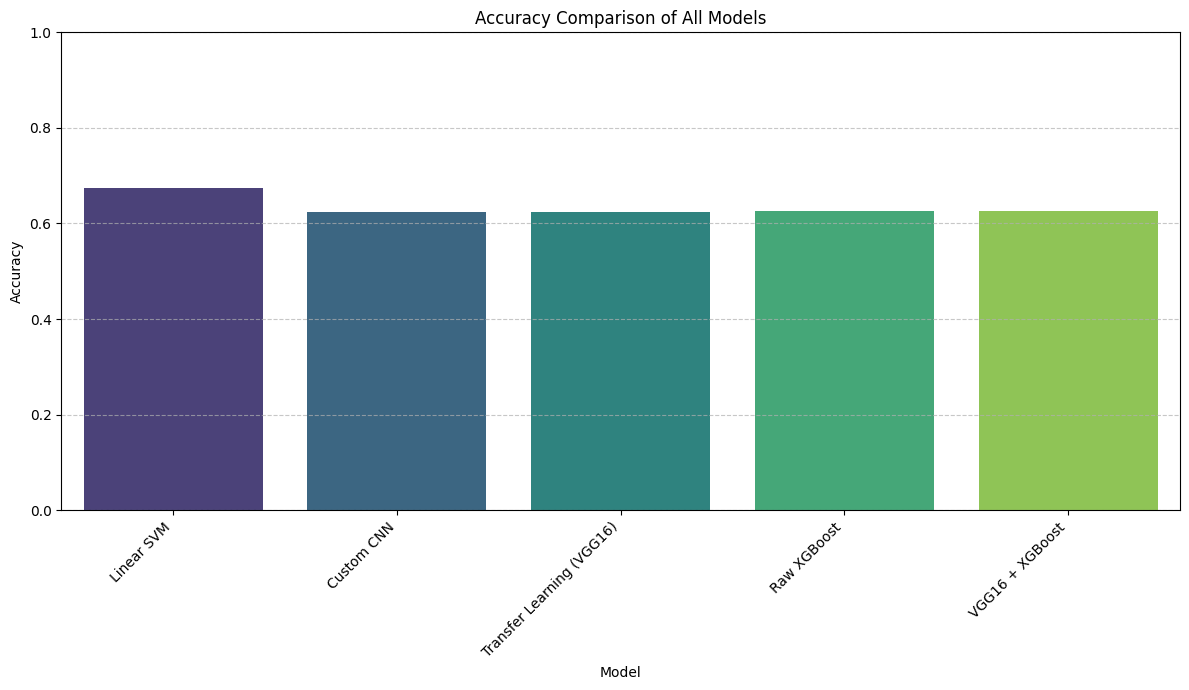

Final model comparison table and accuracy bar chart generated.
Note: XGBoost models are now included in this comparison.


In [18]:
# Combine results from all models into a single DataFrame
all_results = pd.concat([svm_results_df, cnn_results_df, tl_results_df, xgb_raw_results_df, xgb_vgg16_results_df], ignore_index=True)

# Display the final comparison table
print("\n--- FINAL MODEL COMPARISON TABLE ---")
display(all_results)

# Plotting a bar chart for Accuracy comparison
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=all_results, palette='viridis')
plt.title('Accuracy Comparison of All Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('model_accuracy_comparison.png')
plt.show()

print("Final model comparison table and accuracy bar chart generated.")
print("Note: XGBoost models are now included in this comparison.")

### F1-Score Comparison of All Models

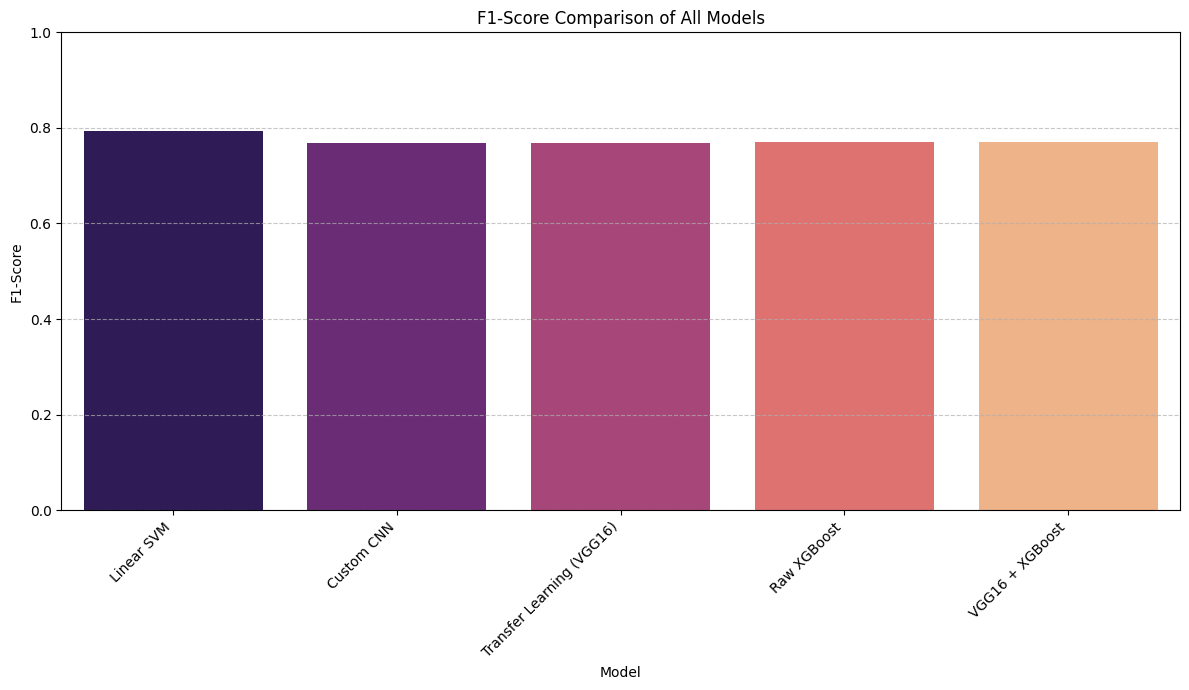

F1-Score comparison bar chart generated.


In [27]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='F1-Score', data=all_results, palette='magma', hue='Model', legend=False)
plt.title('F1-Score Comparison of All Models')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.ylim(0, 1) # F1-Score is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('model_f1_score_comparison.png')
plt.show()

print("F1-Score comparison bar chart generated.")

In [28]:
# Export the all_results DataFrame to a CSV file
all_results.to_csv('model_comparison_results.csv', index=False)
print("All model comparison results exported to 'model_comparison_results.csv'.")

All model comparison results exported to 'model_comparison_results.csv'.


### Specificity Comparison of All Models

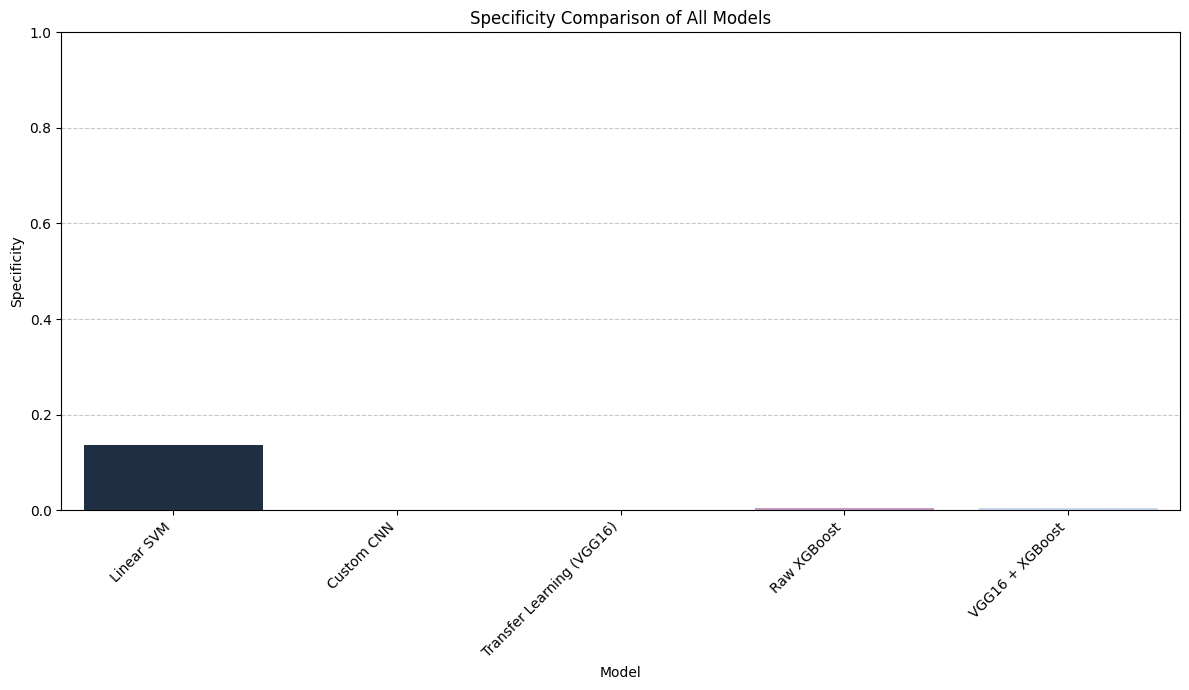

Specificity comparison bar chart generated.


In [29]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Specificity', data=all_results, palette='cubehelix', hue='Model', legend=False)
plt.title('Specificity Comparison of All Models')
plt.xlabel('Model')
plt.ylabel('Specificity')
plt.ylim(0, 1) # Specificity is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('model_specificity_comparison.png')
plt.show()

print("Specificity comparison bar chart generated.")

### STEP 9: XGBOOST IMPLEMENTATION

#### 9.1 Raw XGBoost (Flattened Features)


--- STEP 9.1: RAW XGBOOST (Flattened Features) ---
Training Raw XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:03:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Raw XGBoost training complete.
Evaluating Raw XGBoost model...
Raw XGBoost Results saved to xgboost_raw_results.csv


,Model,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score
0,Raw XGBoost,0.626603,0.626003,1.0,0.004274,0.76999


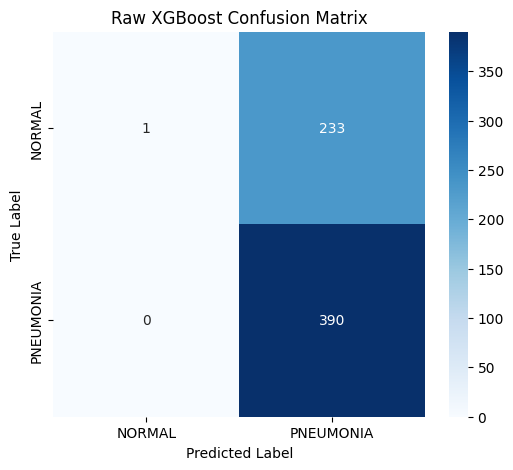

Raw XGBoost model saved as xgboost_raw_model.joblib
Raw XGBoost Implementation Complete.


In [16]:
import xgboost as xgb
import joblib

print("\n--- STEP 9.1: RAW XGBOOST (Flattened Features) ---")

# Reuse X_train_scaled and X_test_scaled from SVM step
# Ensure labels are in the correct format for XGBoost (0 or 1)
y_train_xgb = y_train.astype(int)
y_test_xgb = y_test.astype(int)

# Initialize and train XGBoost classifier
print("Training Raw XGBoost model...")
xgb_raw_model = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    eval_metric='logloss',       # Evaluation metric
    use_label_encoder=False,     # Suppress warning for older versions
    n_estimators=100,            # Number of boosting rounds
    learning_rate=0.1,           # Step size shrinkage
    random_state=42,
    scale_pos_weight=scale_pos_weight # Apply scale_pos_weight here
)
xgb_raw_model.fit(X_train_scaled, y_train_xgb)
print("Raw XGBoost training complete.")

# Evaluate Raw XGBoost model
print("Evaluating Raw XGBoost model...")
y_pred_xgb_raw = xgb_raw_model.predict(X_test_scaled)

xgb_raw_metrics, xgb_raw_cm = evaluate_model(y_test_xgb, y_pred_xgb_raw, 'Raw XGBoost')

# Save Raw XGBoost results
xgb_raw_results_df = pd.DataFrame([xgb_raw_metrics])
xgb_raw_results_df.to_csv('xgboost_raw_results.csv', index=False)
print("Raw XGBoost Results saved to xgboost_raw_results.csv")
display(xgb_raw_results_df)

# Plot confusion matrix
plot_confusion_matrix(xgb_raw_cm, CLASS_LABELS, 'Raw XGBoost Confusion Matrix', 'xgboost_raw_confusion_matrix.png')

# Save the model
joblib.dump(xgb_raw_model, 'xgboost_raw_model.joblib')
print("Raw XGBoost model saved as xgboost_raw_model.joblib")

print("Raw XGBoost Implementation Complete.")

#### 9.2 VGG16 + XGBoost (Feature Extraction)


--- STEP 9.2: VGG16 + XGBOOST (Feature Extraction) ---
Loading VGG16 model for feature extraction...
Extracting VGG16 features from training, validation, and test sets...
VGG16 Train features shape: (989, 8192), Train labels shape: (989,)
VGG16 Validation features shape: (246, 8192), Validation labels shape: (246,)
VGG16 Test features shape: (624, 8192), Test labels shape: (624,)
Training XGBoost model on VGG16 features...
XGBoost on VGG16 features training complete.
Evaluating XGBoost on VGG16 features...
VGG16 + XGBoost Results saved to xgboost_vgg16_results.csv


,Model,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score
0,VGG16 + XGBoost,0.626603,0.626003,1.0,0.004274,0.76999


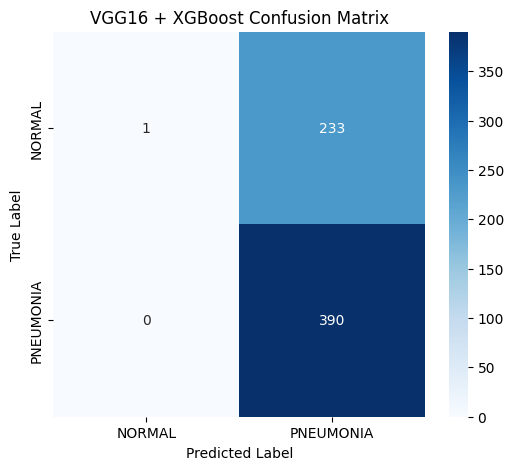

VGG16 + XGBoost model saved as xgboost_vgg16_model.joblib
VGG16 + XGBoost Implementation Complete.


In [17]:
print("\n--- STEP 9.2: VGG16 + XGBOOST (Feature Extraction) ---")

# Load VGG16 base model without top classification layer
print("Loading VGG16 model for feature extraction...")
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Create a model that outputs features from VGG16
vgg16_feature_extractor = Model(inputs=vgg16_base.input, outputs=Flatten()(vgg16_base.output))

# Function to extract features using the VGG16 feature extractor
def extract_vgg16_features(generator, feature_extractor):
    features = []
    labels = []
    # Reset generator to ensure data is processed from the beginning
    generator.reset()
    for _ in range(len(generator)):
        batch_images, batch_labels = next(generator)
        batch_features = feature_extractor.predict(batch_images, verbose=0)
        features.extend(batch_features)
        labels.extend(batch_labels)
    return np.array(features), np.array(labels)

print("Extracting VGG16 features from training, validation, and test sets...")
X_train_vgg16, y_train_vgg16 = extract_vgg16_features(train_generator, vgg16_feature_extractor)
X_val_vgg16, y_val_vgg16 = extract_vgg16_features(validation_generator, vgg16_feature_extractor)
X_test_vgg16, y_test_vgg16 = extract_vgg16_features(test_generator, vgg16_feature_extractor)

print(f"VGG16 Train features shape: {X_train_vgg16.shape}, Train labels shape: {y_train_vgg16.shape}")
print(f"VGG16 Validation features shape: {X_val_vgg16.shape}, Validation labels shape: {y_val_vgg16.shape}")
print(f"VGG16 Test features shape: {X_test_vgg16.shape}, Test labels shape: {y_test_vgg16.shape}")

# Ensure labels are in the correct format for XGBoost (0 or 1)
y_train_vgg16_xgb = y_train_vgg16.astype(int)
y_test_vgg16_xgb = y_test_vgg16.astype(int)

# Train XGBoost on VGG16 features
print("Training XGBoost model on VGG16 features...")
xgb_vgg16_model = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    eval_metric='logloss',       # Evaluation metric
    n_estimators=100,            # Number of boosting rounds
    learning_rate=0.1,           # Step size shrinkage
    random_state=42,
    scale_pos_weight=scale_pos_weight # Apply scale_pos_weight here
)
xgb_vgg16_model.fit(X_train_vgg16, y_train_vgg16_xgb)
print("XGBoost on VGG16 features training complete.")

# Evaluate XGBoost on VGG16 features
print("Evaluating XGBoost on VGG16 features...")
y_pred_xgb_vgg16 = xgb_vgg16_model.predict(X_test_vgg16)

xgb_vgg16_metrics, xgb_vgg16_cm = evaluate_model(y_test_vgg16_xgb, y_pred_xgb_vgg16, 'VGG16 + XGBoost')

# Save VGG16 + XGBoost results
xgb_vgg16_results_df = pd.DataFrame([xgb_vgg16_metrics])
xgb_vgg16_results_df.to_csv('xgboost_vgg16_results.csv', index=False)
print("VGG16 + XGBoost Results saved to xgboost_vgg16_results.csv")
display(xgb_vgg16_results_df)

# Plot confusion matrix
plot_confusion_matrix(xgb_vgg16_cm, CLASS_LABELS, 'VGG16 + XGBoost Confusion Matrix', 'xgboost_vgg16_confusion_matrix.png')

# Save the model
joblib.dump(xgb_vgg16_model, 'xgboost_vgg16_model.joblib')
print("VGG16 + XGBoost model saved as xgboost_vgg16_model.joblib")

print("VGG16 + XGBoost Implementation Complete.")

### STEP 5: CNN IMPLEMENTATION


--- STEP 5: CNN IMPLEMENTATION ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,037,121 (72.62 MB)

...

 Non-trainable params: 1,472 (5.75 KB)

Setting up CNN training callbacks...
Training Custom CNN model...
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.5341 - loss: 2.0143
Epoch 1: val_accuracy improved from None to 0.00446, saving model to best_custom_cnn_model.h5



Epoch 1: finished saving model to best_custom_cnn_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 30s 592ms/step - accuracy: 0.5208 - loss: 1.2990 - val_accuracy: 0.0045 - val_loss: 2.4116 - learning_rate: 0.0010
Epoch 2/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 2:36 5s/step - accuracy: 0.5172 - loss: 0.5685

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.00446
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.5172 - loss: 0.5685 - val_accuracy: 0.0045 - val_loss: 2.5134 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.5735 - loss: 0.5882
Epoch 3: val_accuracy did not improve from 0.00446
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 544ms/step - accuracy: 0.5904 - loss: 0.5371 - val_accuracy: 0.0045 - val_loss: 5.3223 - learning_rate: 0.0010
Epoch 4/100
 1/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7188 - loss: 0.3001
Epoch 4: val_accuracy did not improve from 0.00446
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.7188 - loss: 0.3001 - val_accuracy: 0.0045 - val_loss: 6.0586 - learning_rate: 0.0010
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.6598 - loss: 0.3847
Epoch 5: val_accuracy did not improve from 0.00446
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 534ms/step - accuracy: 0.6897 - loss: 0.3383 - val_accuracy: 0.0045 - val_loss: 10

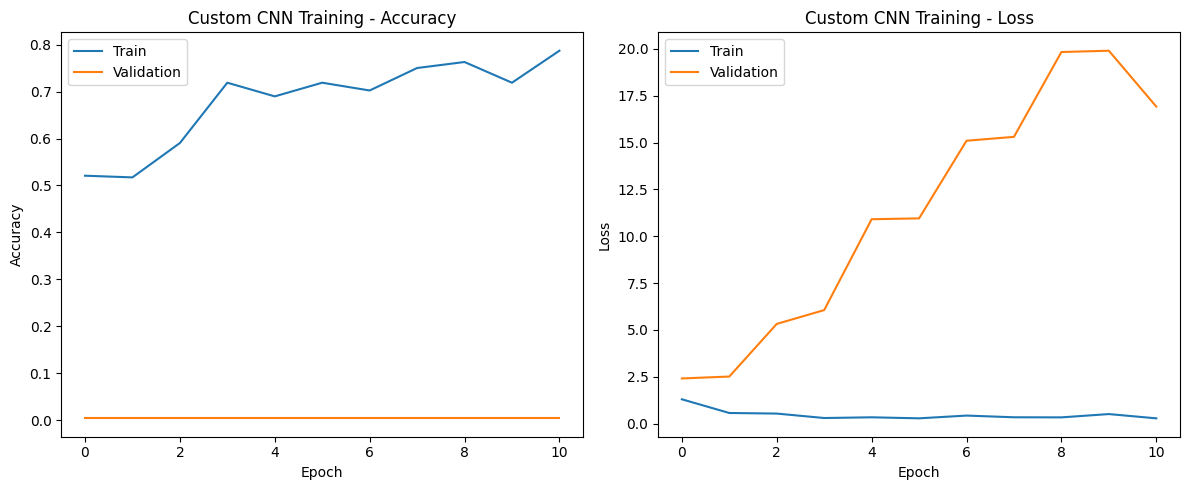

Evaluating Custom CNN model...
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 394ms/step
Custom CNN Results saved to custom_cnn_results.csv


,Model,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score
0,Custom CNN,0.375,0.0,0.0,1.0,0.0


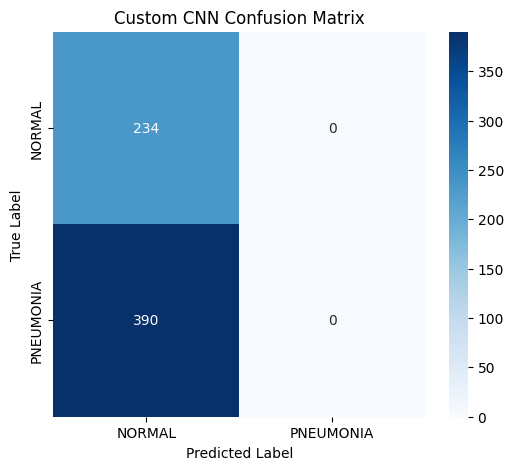

CNN Implementation Complete.


In [24]:
print("\n--- STEP 5: CNN IMPLEMENTATION ---")

# Function to build custom CNN model
def build_custom_cnn(input_shape):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid') # Binary classification
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build the CNN model
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3) # 3 for RGB images
custom_cnn_model = build_custom_cnn(input_shape)
custom_cnn_model.summary()

# Define callbacks
print("Setting up CNN training callbacks...")
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_custom_cnn_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
]

# Train the CNN model
print("Training Custom CNN model...")
epochs = 100 # Train for at least 100 epochs as per requirement
history_cnn = custom_cnn_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights_dict # Apply class weights here
)

print("Custom CNN training complete.")

# Plot training curves
plot_training_curves(history_cnn, 'Custom CNN Training', 'custom_cnn_training_curves.png')

# Evaluate CNN model
print("Evaluating Custom CNN model...")
custom_cnn_model.load_weights('best_custom_cnn_model.h5') # Load best weights
y_pred_cnn_probs = custom_cnn_model.predict(test_generator)
y_pred_cnn = (y_pred_cnn_probs > 0.5).astype(int).flatten()

# Get true labels from test_generator
true_labels_cnn = test_generator.classes[test_generator.index_array]

cnn_metrics, cnn_cm = evaluate_model(true_labels_cnn, y_pred_cnn, 'Custom CNN')

# Save CNN results
cnn_results_df = pd.DataFrame([cnn_metrics])
cnn_results_df.to_csv('custom_cnn_results.csv', index=False)
print("Custom CNN Results saved to custom_cnn_results.csv")
display(cnn_results_df)

# Plot confusion matrix
plot_confusion_matrix(cnn_cm, CLASS_LABELS, 'Custom CNN Confusion Matrix', 'custom_cnn_confusion_matrix.png')

print("CNN Implementation Complete.")

In [3]:
def evaluate_model(y_true, y_pred, model_name):
    """Evaluates model performance and returns metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_true, y_pred, average='binary', zero_division=0) # Sensitivity

    cm = confusion_matrix(y_true, y_pred)
    # Specificity = TN / (TN + FP)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        # Handle cases where confusion matrix might not be 2x2 (e.g., all predictions are one class)
        specificity = 0 # Or handle as appropriate for your multi-class scenario if applicable

    f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall (Sensitivity)': recall,
        'Specificity': specificity,
        'F1-Score': f1
    }
    return metrics, cm

def plot_confusion_matrix(cm, labels, title, filename=None):
    """Plots the confusion matrix."""
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    if filename:
        plt.savefig(filename)
    plt.show()

def plot_training_curves(history, title, filename=None):
    """Plots training and validation accuracy and loss curves."""
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + ' - Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + ' - Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    if filename:
        plt.savefig(filename)
    plt.show()

print("Utility functions defined.")

Utility functions defined.


## EXERCISE 2: CHEST X-RAY DATASET (SVM + CNN)

### STEP 1: Load Chest X-ray dataset (train/test/val folders)

In [7]:
# Define image dimensions and batch size
IMG_HEIGHT, IMG_WIDTH = 150, 150
BATCH_SIZE = 32

# Path to the 'val' directory
VAL_DIR = os.path.join(DATASET_PATH, 'val')

# Check if the 'val' directory exists, if not, create it by splitting from 'train'
if not os.path.exists(VAL_DIR) or (os.path.exists(VAL_DIR) and (not os.listdir(os.path.join(VAL_DIR, 'NORMAL')) or not os.listdir(os.path.join(VAL_DIR, 'PNEUMONIA')))):
    print("Validation directory not found or empty. Creating one from training data...")
    os.makedirs(os.path.join(VAL_DIR, 'NORMAL'), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, 'PNEUMONIA'), exist_ok=True)

    train_normal_dir = os.path.join(DATASET_PATH, 'train', 'NORMAL')
    train_pneumonia_dir = os.path.join(DATASET_PATH, 'train', 'PNEUMONIA')

    # Get all images for NORMAL and PNEUMONIA classes
    normal_images = os.listdir(train_normal_dir)
    pneumonia_images = os.listdir(train_pneumonia_dir)

    # Shuffle and select a percentage for validation (e.g., 20%)
    random.shuffle(normal_images)
    random.shuffle(pneumonia_images)

    val_split_ratio = 0.20 # 20% of training data for validation

    num_val_normal = int(len(normal_images) * val_split_ratio)
    num_val_pneumonia = int(len(pneumonia_images) * val_split_ratio)

    # Move selected images to the new 'val' directory
    for img_name in normal_images[:num_val_normal]:
        shutil.move(os.path.join(train_normal_dir, img_name),
                    os.path.join(VAL_DIR, 'NORMAL', img_name))
    for img_name in pneumonia_images[:num_val_pneumonia]:
        shutil.move(os.path.join(train_pneumonia_dir, img_name),
                    os.path.join(VAL_DIR, 'PNEUMONIA', img_name))
    print(f"Moved {num_val_normal} NORMAL and {num_val_pneumonia} PNEUMONIA images to validation set.")
else:
    print("Validation directory already exists and is populated.")

# Create ImageDataGenerator for training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# ImageDataGenerator for validation and test sets (only rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'train'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True # Shuffle training data
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Do not shuffle validation data for consistent evaluation
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'test'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Do not shuffle test data for consistent evaluation
)

print("Dataset loaded successfully into generators.")
print(f"Class labels: {train_generator.class_indices}")
CLASS_LABELS = list(train_generator.class_indices.keys())


Validation directory not found or empty. Creating one from training data...
Moved 1 NORMAL and 245 PNEUMONIA images to validation set.
Found 989 images belonging to 2 classes.
Found 246 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Dataset loaded successfully into generators.
Class labels: {'NORMAL': 0, 'PNEUMONIA': 1}


### STEP 2: Data Exploration

Class Distribution Table:


,Train,Validation,Test
PNEUMONIA,982,245,390
NORMAL,7,1,234


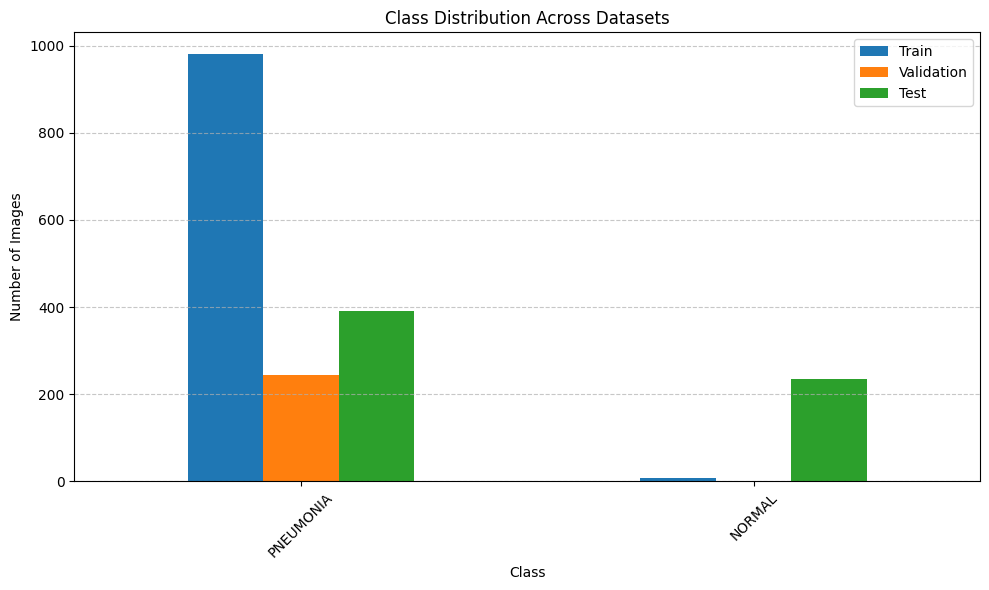

In [8]:
# Display class distribution (table and histogram)
def get_class_distribution(directory):
    class_counts = {}
    if not os.path.exists(directory):
        return {'NORMAL': 0, 'PNEUMONIA': 0} # Return 0 for missing directory
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    return class_counts

train_class_counts = get_class_distribution(os.path.join(DATASET_PATH, 'train'))
val_class_counts = get_class_distribution(os.path.join(DATASET_PATH, 'val'))
test_class_counts = get_class_distribution(os.path.join(DATASET_PATH, 'test'))

class_dist_df = pd.DataFrame({
    'Train': train_class_counts,
    'Validation': val_class_counts,
    'Test': test_class_counts
}).fillna(0).astype(int)

print("Class Distribution Table:")
display(class_dist_df)

# Plot histogram of class counts
class_dist_df.plot(kind='bar', figsize=(10, 6))
plt.title('Class Distribution Across Datasets')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('class_distribution_histogram.png')
plt.show()


Sample Images from Training Set:


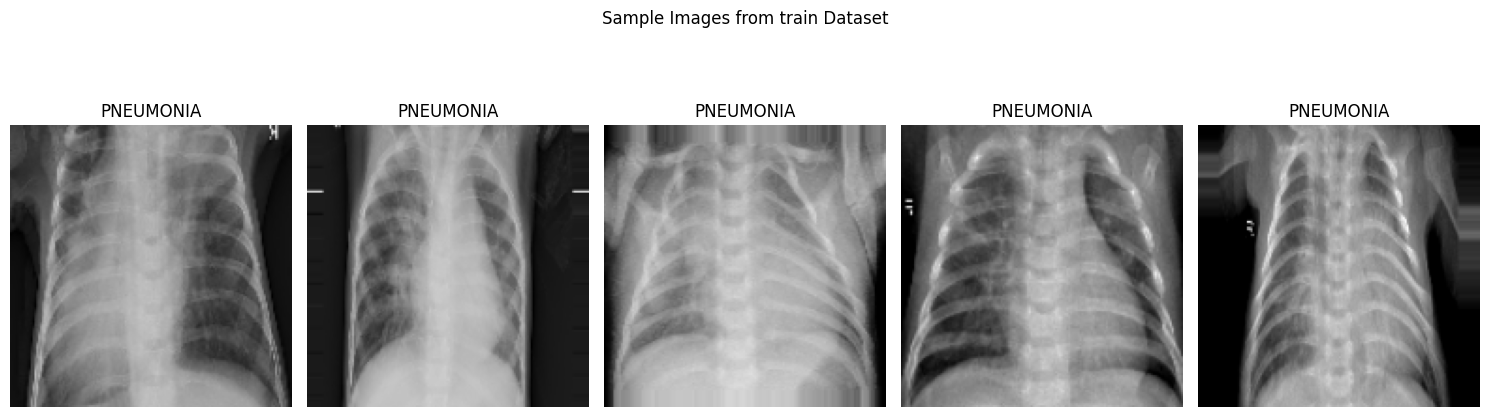


Sample Images from Validation Set:


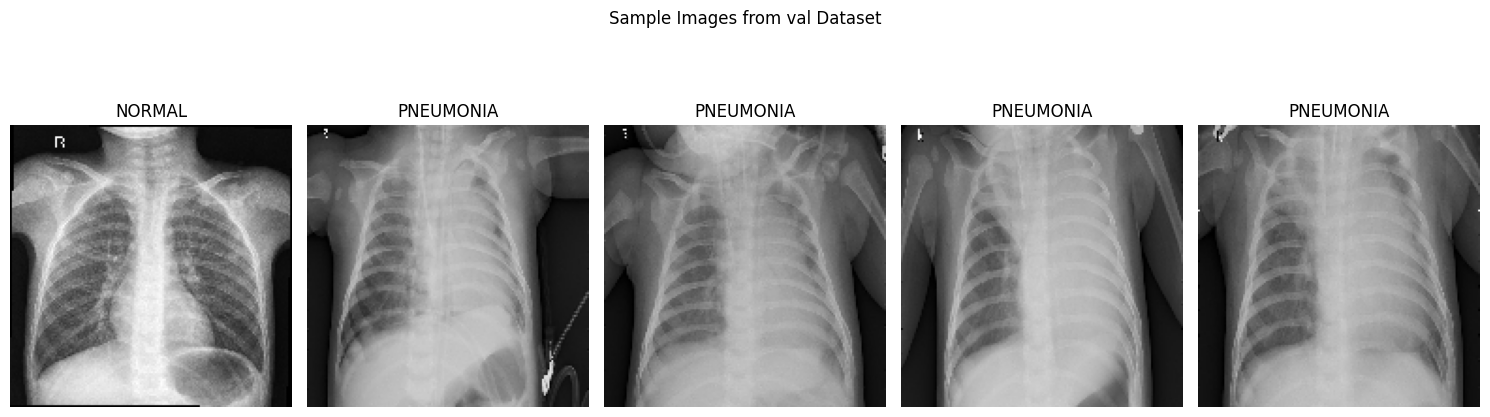


Sample Images from Test Set:


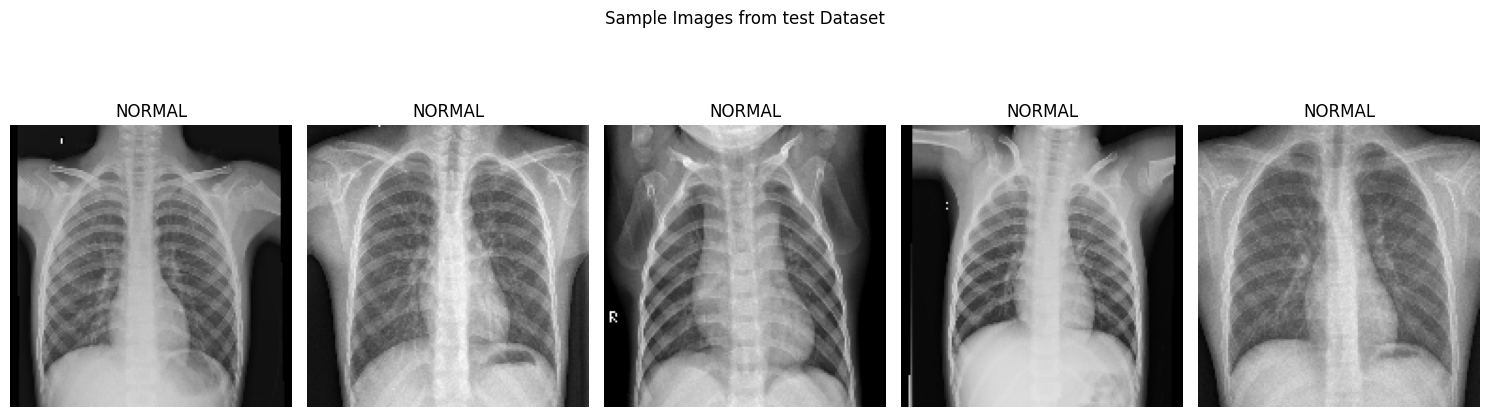

In [9]:
# Show sample images
def show_sample_images(generator, num_samples=5):
    images, labels = next(generator) # Get a batch of images and labels
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i])
        plt.title(CLASS_LABELS[int(labels[i])])
        plt.axis('off')
    plt.suptitle(f'Sample Images from {generator.directory.split(os.sep)[-1]} Dataset')
    plt.tight_layout()
    plt.show()

print("\nSample Images from Training Set:")
show_sample_images(train_generator, num_samples=5)

print("\nSample Images from Validation Set:")
show_sample_images(validation_generator, num_samples=5)

print("\nSample Images from Test Set:")
show_sample_images(test_generator, num_samples=5)

### STEP 3: Data Preprocessing (handled by ImageDataGenerator)

- **Normalization**: Images are rescaled to `[0, 1]` range by `rescale=1./255` in `ImageDataGenerator`.
- **Augmentation**: Applied to the training set using `shear_range`, `zoom_range`, and `horizontal_flip`.

### STEP 4: SVM IMPLEMENTATION


--- STEP 4: SVM IMPLEMENTATION ---
Extracting features for SVM...
Train features shape: (989, 67500), Train labels shape: (989,)
Validation features shape: (246, 67500), Validation labels shape: (246,)
Test features shape: (624, 67500), Test labels shape: (624,)
Scaling features...
Training Linear SVM...
SVM training complete.
Evaluating SVM...
SVM Results saved to svm_results.csv


,Model,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score
0,Linear SVM,0.644231,0.637255,1.0,0.051282,0.778443


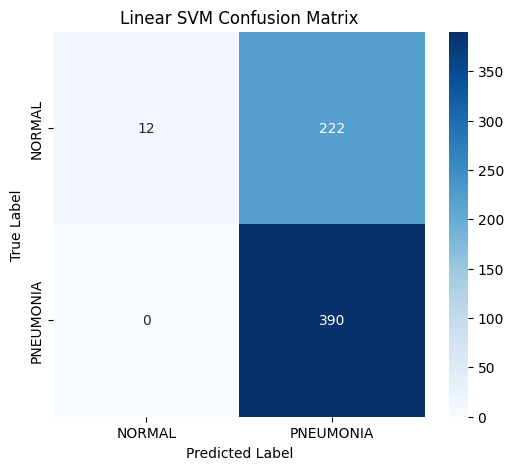

SVM Implementation Complete.


In [20]:
print("\n--- STEP 4: SVM IMPLEMENTATION ---")

# Function to extract image features (flattened pixels)
def extract_features(generator):
    features = []
    labels = []
    # Reset generator to ensure data is processed from the beginning
    generator.reset()
    for _ in range(len(generator)):
        batch_images, batch_labels = next(generator)
        # Flatten images and append
        features.extend(batch_images.reshape(batch_images.shape[0], -1))
        labels.extend(batch_labels)
    return np.array(features), np.array(labels)

print("Extracting features for SVM...")
X_train, y_train = extract_features(train_generator)
X_val, y_val = extract_features(validation_generator)
X_test, y_test = extract_features(test_generator)

print(f"Train features shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Validation features shape: {X_val.shape}, Validation labels shape: {y_val.shape}")
print(f"Test features shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# Apply scaling to features
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train SVM (LINEAR kernel)
print("Training Linear SVM...")
svm_model = SVC(kernel='linear', random_state=42, class_weight=class_weights_dict)
svm_model.fit(X_train_scaled, y_train)
print("SVM training complete.")

# Evaluate SVM
print("Evaluating SVM...")
y_pred_svm = svm_model.predict(X_test_scaled)
svm_metrics, svm_cm = evaluate_model(y_test, y_pred_svm, 'Linear SVM')

# Save SVM results
svm_results_df = pd.DataFrame([svm_metrics])
svm_results_df.to_csv('svm_results.csv', index=False)
print("SVM Results saved to svm_results.csv")
display(svm_results_df)

# Plot confusion matrix
plot_confusion_matrix(svm_cm, CLASS_LABELS, 'Linear SVM Confusion Matrix', 'svm_confusion_matrix.png')

print("SVM Implementation Complete.")

In [19]:
from sklearn.utils import class_weight

# Calculate class weights for imbalanced dataset
# Using y_train which is already extracted for SVM and represents the training labels
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Calculated Class Weights: {class_weights_dict}")

# For XGBoost, we often use scale_pos_weight which is (count_negative_samples / count_positive_samples)
# Assuming 0 is NORMAL (minority) and 1 is PNEUMONIA (majority) based on previous exploration
# If 0 is PNEUMONIA and 1 is NORMAL, then reverse the order.
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_pos_weight = neg_count / pos_count

print(f"XGBoost scale_pos_weight: {scale_pos_weight}")

Calculated Class Weights: {0: np.float64(70.64285714285714), 1: np.float64(0.5035641547861507)}
XGBoost scale_pos_weight: 0.007128309572301426
